In [14]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [15]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from  src.model_siamese import SiameseUNet
from torch.amp import GradScaler

scaler = GradScaler('cuda')

In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [17]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 4
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 15
BASE_FEATURES = 24
SAVE_PATH = "best_siamese_unet_combo.pth"

In [18]:
# Create Data Splits
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [19]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=True, augment_train=True)

In [20]:
# Sanity check
pre, post, masks = next(iter(train_loader))

print(f"Pre image:  {pre.shape}")    # [B, 3, H, W]
print(f"Post image: {post.shape}")   # [B, 3, H, W]
print(f"Masks:      {masks.shape}")  # [B, H, W]
print(f"Mask range: {masks.min()} – {masks.max()}")
print(f"Device:     {pre.device}")

Pre image:  torch.Size([4, 3, 512, 512])
Post image: torch.Size([4, 3, 512, 512])
Masks:      torch.Size([4, 512, 512])
Mask range: 0 – 3
Device:     cpu


In [21]:
# Inverse Effective Weight
beta = 0.9999
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

effective_num = (1.0 - beta**class_counts) / (1.0 - beta)
weights = 1.0 / effective_num 
weights = weights / weights.min()
class_weights = weights.to(device) 

In [22]:
# Model
model = SiameseUNet(
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES,
    in_channels=3 # only include 3 channels for Siamese
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device)

Model parameters: 5,839,277
cuda:0


In [23]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights, ce_weight=0.3,
                      tversky_weight=0.7, tversky_alpha=0.85, tversky_beta=0.15, tversky_gamma=0.6,
                      ohem_keep_ratio = 0.5,
                      num_classes=NUM_CLASSES).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay = 1e-4)

#scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=2e-4, steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS, pct_start=0.1, div_factor=10, final_div_factor=100)

In [24]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True,
    siamese = True, scaler=scaler)


Epoch 1/50  (lr=2.00e-05)
  Train Loss: 0.9360  |  Val Loss: 0.7912
  Train mIoU: 0.2451  |  Val mIoU: 0.2632
  Train Acc:  0.8942  |  Val Acc:  0.9430
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9417   0.9847   0.9556
    Minor             0.3745   0.4371   0.7235
    Major             0.0000   0.0000   0.0000
    Destroyed         0.0000   0.0000   0.0000
    Unclassified      0.0000   0.0119   0.0000
  *** Saved new best model (mIoU=0.2632) ***


  *** Saved new best model (mIoU=0.3231) ***


  *** Saved new best model (mIoU=0.3631) ***


  *** Saved new best model (mIoU=0.3956) ***



Epoch 5/50  (lr=1.83e-04)
  Train Loss: 0.5510  |  Val Loss: 0.5416
  Train mIoU: 0.4336  |  Val mIoU: 0.3936
  Train Acc:  0.9523  |  Val Acc:  0.9702
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9706   0.9891   0.9810
    Minor             0.5653   0.6839   0.7653
    Major             0.0014   0.0016   0.0092
    Destroyed         0.0285   0.0297   0.4182
    Unclassified      0.4023   0.5408   0.6110


...


Epoch 35/50  (lr=5.63e-05)
  Train Loss: 0.4445  |  Val Loss: 0.5205
  Train mIoU: 0.6044  |  Val mIoU: 0.4235
  Train Acc:  0.9664  |  Val Acc:  0.9775
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9788   0.9901   0.9884
    Minor             0.6354   0.7792   0.7749
    Major             0.0044   0.0046   0.0829
    Destroyed         0.0667   0.0755   0.3622
    Unclassified      0.4322   0.7322   0.5133


  *** Saved new best model (mIoU=0.4340) ***



Epoch 40/50  (lr=2.82e-05)
  Train Loss: 0.4360  |  Val Loss: 0.5196
  Train mIoU: 0.6140  |  Val mIoU: 0.4232
  Train Acc:  0.9677  |  Val Acc:  0.9772
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9778   0.9907   0.9868
    Minor             0.6368   0.7560   0.8014
    Major             0.0062   0.0067   0.0749
    Destroyed         0.0590   0.0673   0.3235
    Unclassified      0.4363   0.7579   0.5069



Epoch 45/50  (lr=8.84e-06)
  Train Loss: 0.4340  |  Val Loss: 0.5198
  Train mIoU: 0.6244  |  Val mIoU: 0.4222
  Train Acc:  0.9678  |  Val Acc:  0.9777
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9786   0.9907   0.9876
    Minor             0.6422   0.7682   0.7965
    Major             0.0049   0.0052   0.0712
    Destroyed         0.0623   0.0711   0.3349
    Unclassified      0.4229   0.7594   0.4883



Epoch 50/50  (lr=4.43e-07)
  Train Loss: 0.4299  |  Val Loss: 0.5176
  Train mIoU: 0.6317  |  Val mIoU: 0.4269
  Train Acc:  0.9689  |  Val Acc:  0.9782
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9789   0.9907   0.9880
    Minor             0.6465   0.7724   0.7985
    Major             0.0039   0.0042   0.0503
    Destroyed         0.0627   0.0743   0.2870
    Unclassified      0.4425   0.7600   0.5144


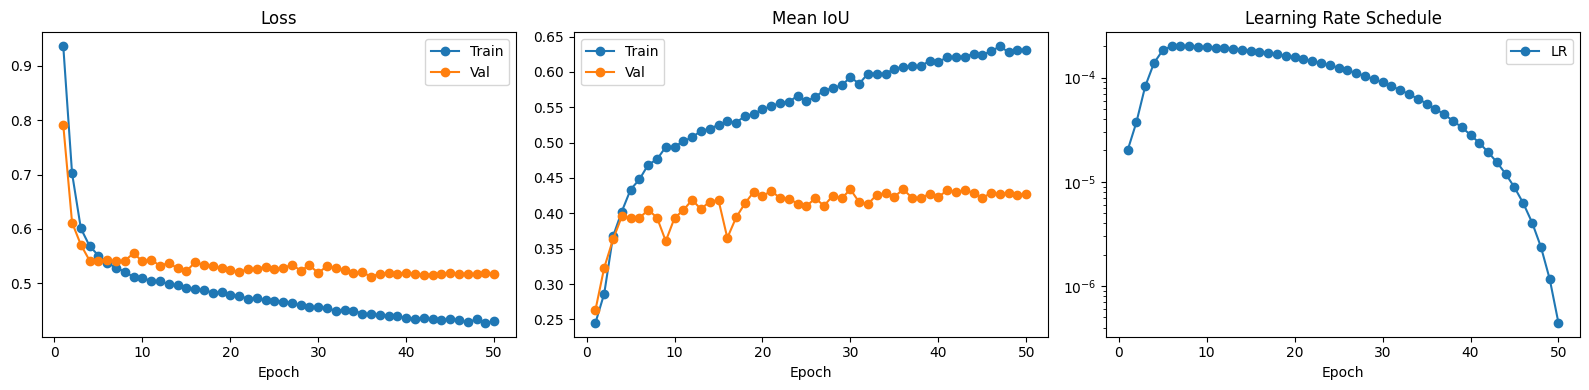

In [25]:
plot_train_history(history)

In [26]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=True)

Test Loss: 0.7230
Test mIoU: 0.3170
Test Acc:  0.9228

Class                IoU     Prec   Recall
No Damage         0.9439   0.9628   0.9796
Minor             0.5866   0.6986   0.7854
Major             0.0174   0.0978   0.0208
Destroyed         0.0149   0.2342   0.0157
Unclassified      0.0219   0.0682   0.0313


In [29]:
COLORS = np.array([
    [0, 0, 0],        # No Damage
    [255, 255, 0],    # Minor
    [255, 165, 0],    # Major
    [255, 0, 0],      # Destroyed
    [128, 128, 128],  # Unclassified
], dtype=np.uint8)


def mask_to_rgb(mask):
    # Converts the mask to colors
    return COLORS[mask]

def denormalize(img):
    # Denormalizes images
    return (img * 0.5 + 0.5).clip(0, 1)


@torch.no_grad()
def visualize_predictions(model, test_loader, device, num_samples=4, title="Model Predictions"):
    """
    Creates a grid of images, where each row is an example and the columns are
    Pre | Post | Ground Truth | Prediction
    """

    model.eval()

    fig, axes = plt.subplots(
        nrows=num_samples,
        ncols=4,
        figsize=(16, 4 * num_samples)
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    shown = 0

    for batch in test_loader:
        pre, post, masks = batch

        pre = pre.to(device)
        post = post.to(device)

        preds = model(pre, post).argmax(dim=1).cpu().numpy()

        pre = pre.cpu().numpy()
        post = post.cpu().numpy()
        masks = masks.numpy()

        B = pre.shape[0]

        for i in range(B):
            if shown >= num_samples:
                plt.suptitle(title, fontsize=16)
                plt.tight_layout()
                plt.show()
                return

            # Images
            pre_img = np.transpose(denormalize(pre[i]), (1, 2, 0))
            post_img = np.transpose(denormalize(post[i]), (1, 2, 0))

            # Masks
            gt_mask = mask_to_rgb(masks[i])
            pred_mask = mask_to_rgb(preds[i])

            ax = axes[shown]

            ax[0].imshow(pre_img)
            ax[0].set_title("Pre")
            ax[0].axis("off")

            ax[1].imshow(post_img)
            ax[1].set_title("Post")
            ax[1].axis("off")

            ax[2].imshow(gt_mask)
            ax[2].set_title("Ground Truth")
            ax[2].axis("off")

            ax[3].imshow(pred_mask)
            ax[3].set_title("Prediction")
            ax[3].axis("off")

            shown += 1

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

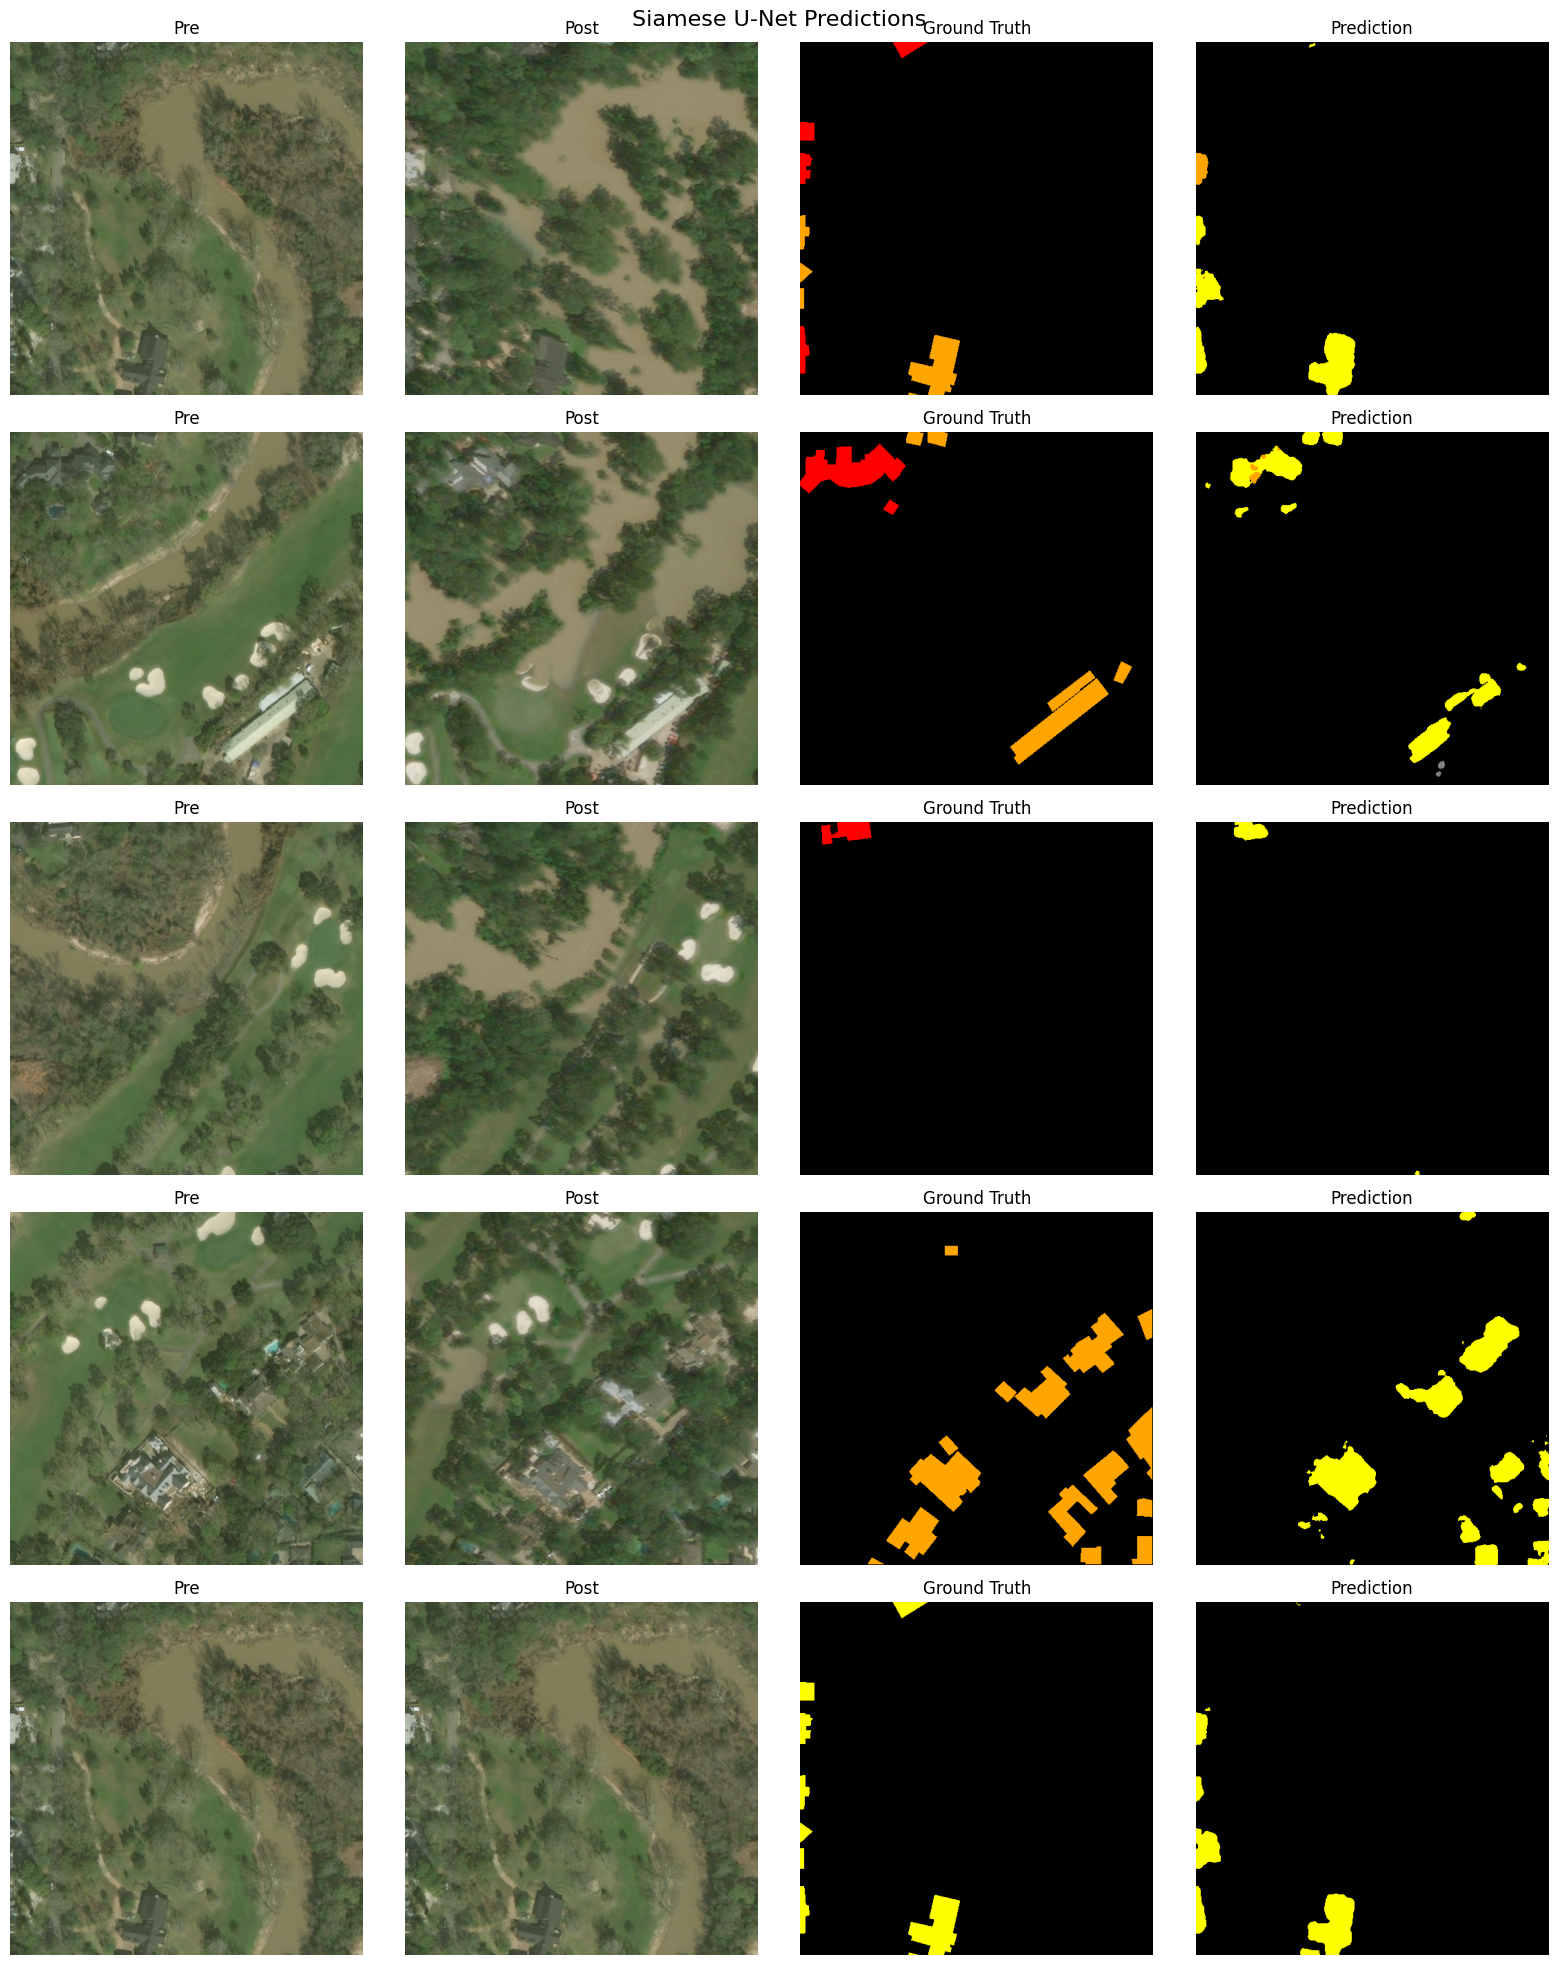

In [30]:
visualize_predictions(model=model, test_loader=test_loader, device=device,
    num_samples=5, title="Siamese U-Net Predictions")